# Анализ рынка общественного питания

- Автор: Козлова Екатерина
- Дата: 29.01.2026-30.01.2026

### Цели и задачи проекта

**Цель проекта** - провести исследовательский анализ рынка общественного питания Москвы (на основе данных лета 2022 года) для обоснования стратегических решений инвесторов фонда Shut Up and Take My Money при запуске нового заведения.

**Задачи проекта:**
1. Загрузка данных и первичное знакомство с ними
2. Предобработка данных, включая проверку корректности данных, их типов, наличия или отсуствия пропусков
3. Провести исследовательский анализ данных
4. Подготовить основные выводы и рекомендации

### Описание данных

**Файл /datasets/rest_info.csv содержит информацию о заведениях общественного питания:**
* name — название заведения;
* address — адрес заведения;
* district — административный район, в котором находится заведение, например Центральный административный округ;
* category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
* hours — информация о днях и часах работы;
* rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
* chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки).


**Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:**
* price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
* avg_bill — хранит среднюю стоимость заказа в виде диапазона;
* middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill;
* middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill.

### Содержимое проекта

* [Загрузка данных и знакомство с ними](#1bullet) 
* [Предобработка данных](#2bullet)
* [Исследовательский анализ данных](#3bullet)
* [Итоговый вывод и рекомендации](#4bullet)

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

- Познакомьтесь с данными и изучите общую информацию о них.

*Загрузим библиотеки и датасеты rest_info.csv и rest_price.csv. Данные сохраним как rest.df и price.df*

In [4]:
# Комментарий ревьюера
# Для задания по расчету корреляции требуется установить библиотеку
# Устанавливаем библиотеку phik
!pip install phik -U    
# Библиотека для расчета коэффициента корреляции phi_k
#from phik import phik_matrix

In [5]:
# Загрузка библиотек для работы с датафреймами
import pandas as pd

# Загрузка библиотек для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка библиотек для расчета коэффициента корреляции
from phik import phik_matrix

In [6]:
rest_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

*Изучим данные датасета rest_info.csv — выведем первые строки методом head() и информацию о датафрейме методом info()*

In [7]:
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [8]:
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


*Изучим данные датасета rest_price.csv — выведем первые строки методом head() и информацию о датафрейме методом info()*

In [9]:
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [10]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датафрейм **rest_df** содержит 8406 строк и 9 столбцов. Представленные данные в целом соответствуют ожидаемой структуре (название заведения, категория, адрес заведения, административный район, данные о днях и часах работы, рейтинг, принадлежность заведения к сети, кол-во посадочных мест). Столбцы имеют корректный типы данных. По представленному датафрейму можно отметить следующее:

* Столбцы hours и seats наблюдаются пропуски, что говорит о том, что их нужно проанализировать. 
* Для экономии памяти и большей информативности размерность столбцов rating, chain, seats можно понизить.
* Столбец seats корректнее будет ещё по возможности привести к целочисленному типу, т.к. не бывает 0,5 мест в заведении, например. Однако поскольку данные значения индивидуальны для каждого из заведений, то привести к данному типу может быть невозможно.

Датафрейм **price_df** содержит 4058 строк и 5 столбцов. Представленные данные в целом соответствуют ожидаемой структуре (id, цена, средняя стоимость заказа, средний чек, оценка одной чашки капучино). Столбцы имеют корректный типы данных. По представленному датафрейму можно отметить следующее:

* Значительная доля пропусков наблюдается в столбцах price, avg_bill, middle_avg_bill и middle_coffee_cup. Данные пропуски необходимо будет проанализировать в дальнейшем.
* Размерность столбцов middle_avg_bill, middle_coffee_cup можно снизить.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

Так как основная цель проекта изучить рынок общественно питания, то для более корректной работы, правильнее объеденить датафрейм rest_df (информация о заведениях) и датафрейм price_df (информация о среднем чеке в заведениях). Датафреймы объеденим по столбцу "id".

In [11]:
df = rest_df.merge(price_df, on='id', how='left')

In [12]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [14]:
# Комментарий ревьюера
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = df.copy() 
len(temp)

8406

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [15]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Во время предварительного знакомства с данными было определено, что столбцы rating, chain, middle_avg_bill, middle_coffee_cup и  seats можно понизить.

In [16]:
df['rating'] = pd.to_numeric(df['rating'], downcast='float', errors='coerce')
df['chain'] = pd.to_numeric(df['chain'], downcast='integer', errors='coerce')

In [17]:
for column in ['middle_avg_bill','middle_coffee_cup','seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [18]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

Мы видим, что столбец seats содержит 3 611 пропусков, что говорит о том, что данные в нем сначало необходимо обработать и только после этого при необходимости менять на целочисленный тип.

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

Посчитаем абсолютное и относительное количество пропусков для каждого столбца.

In [19]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [20]:
df.isna().sum() / len(df) * 100

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

По результатам изучения пропусков можно сказать следующее:
* В столбцах id, name, category, address, district, rating, chain пропуски отсутствуют
* Среднее количество пропусков в столбце hours (536). Можно предположить, что пропуски в данном столбце связаны с нестандартным графиком работы, невнесением данных, заведение временно не работает и т.д. Правильным считаю оставить их как NaN.
* Столбец seats содержит 3611 пропусков. В качестве причин этого может быть - данные заведения небольшие и поэтому кол-во посадочных мест не так важно, в заведении просто не указано кол-во посадочных мест, официально данные о их кол-ве не раскрывались и т.д. Заменять пропуски на индикаторы считаю некорректным и думаю правильным будет оставить их как NaN.
* Столбцы avg_bill и price содержат 4590 и 5091 пропусков соответственно. Причинами пропусков могут быть отсутствие данных, отсутствие установленной ценовой политики, изменяемости цен (акции и т.д.). Правильным будет оставить их как NaN.
* Больше всего пропусков в столбцах middle_avg_bill (5257) и middle_coffee_cup (7871). Данные пропуски не считаю корректным обрабатывать, так как это может исказить анализ.

In [22]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

Проверим уникальные значения в категориальных столбцах 

In [23]:
for column_name in ['category', 'district', 'chain', 'price']:
    display(f"Колонка: {column_name}")
    
    unique_values = df[column_name].unique()
    display(f"Уникальные значения: {unique_values}")
    
    unique_count = df[column_name].nunique()
    display(f"Количество уникальных значений: {unique_count}")

'Колонка: category'

"Уникальные значения: ['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'\n 'булочная' 'столовая']"

'Количество уникальных значений: 8'

'Колонка: district'

"Уникальные значения: ['Северный административный округ'\n 'Северо-Восточный административный округ'\n 'Северо-Западный административный округ'\n 'Западный административный округ' 'Центральный административный округ'\n 'Восточный административный округ' 'Юго-Восточный административный округ'\n 'Южный административный округ' 'Юго-Западный административный округ']"

...

'Уникальные значения: [0 1]'

'Количество уникальных значений: 2'

'Колонка: price'

"Уникальные значения: [nan 'выше среднего' 'средние' 'высокие' 'низкие']"

'Количество уникальных значений: 4'

Проверяем полные дубликаты в датафрейме

In [24]:
df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты.

Проверим неявные дубликаты — значения по id заведений должны быть уникальными, то есть каждая строка в данных — уникальное заведение.

In [25]:
df.duplicated(subset='id').sum()

0

Мы видим, что дубликатов в столбце id нет, а значиткаждая строка принадлежит уникальному заведению. 

Теперь проверим корректность написания категориальных значений в данных: название, категория, адрес, округ.

Приведем столбцы name, category и address к нижнему регистру и удалим конечные пробелы для корректного поиска неявных дубликатов.

In [26]:
for column in ['name', 'category', 'address']:
    df[column] = df[column].str.lower().str.strip()

In [27]:
df.duplicated(subset=['name', 'category', 'address']).sum()

2

In [28]:
df.duplicated(subset=['name', 'address']).sum()

4

Выведем найденные 4 дубликата

In [29]:
df[df.duplicated(subset=['name', 'address'])]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


In [30]:
df[df.duplicated(subset=['name', 'category', 'address'])]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN


Определим количество строк до удаления дубликатов и удалим дубликаты

In [31]:
str_all = len(df)
display(f'Количество строк до удаления: {str_all}')
cleaned_str = df.drop_duplicates()

'Количество строк до удаления: 8406'

In [32]:
df = df.drop_duplicates(subset=['name', 'address'], keep='first', inplace=False)

In [33]:
df[df.duplicated(subset=['name', 'address'])]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup


Видим, что дубликатов не найдено.

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

Проверим, содержит ли столбец hours подстроку "круглосуточно" / "ежедневно" и не являются NaN и создадим новый столбец is_24_7

In [34]:
display("Сколько записей содержат 'круглосуточно' или 'ежедневно':")
display(df[df['hours'].str.contains('круглосуточно|ежедневно', na=False)]['hours'].value_counts())

"Сколько записей содержат 'круглосуточно' или 'ежедневно':"

ежедневно, 10:00–22:00                                                 758
ежедневно, круглосуточно                                               730
ежедневно, 11:00–23:00                                                 396
ежедневно, 10:00–23:00                                                 310
ежедневно, 12:00–00:00                                                 254
                                                                      ... 
ежедневно, 10:30–22:45                                                   1
пн-пт круглосуточно; сб 09:00–22:00; вс круглосуточно                    1
ежедневно, 09:00–23:45                                                   1
пн-чт 10:00–23:00; пт 10:00–00:00; сб круглосуточно; вс 00:00–23:00      1
ежедневно, 10:00–19:30                                                   1
Name: hours, Length: 276, dtype: int64

In [35]:
def all_day(value):
    if value == 'ежедневно, круглосуточно':
        return True
    return False

In [36]:
df['is_24_7'] = df['hours'].apply(all_day)

In [37]:
df.tail(10)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
8396,4277890d659341848d7051cbf2e51f51,пекинский двор,ресторан,"москва, ленинский проспект, 158",Западный административный округ,"ежедневно, 11:00–23:00",4.3,0,200.0,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN,False
8397,026cbc478f9b4c3294a83458dcd89982,траектория крафт-кафе,пиццерия,"москва, улица лобачевского, 52, корп. 1",Западный административный округ,"пн-пт 10:00–23:00; сб,вс 12:00–23:00",4.4,0,60.0,средние,NaN,NaN,NaN,False
8398,324cceddf3164617b4dbd9b6fae25d07,на волгина,кафе,"москва, улица академика волгина, 2а",Юго-Западный административный округ,"ежедневно, 09:00–23:00",4.4,0,49.0,NaN,NaN,NaN,NaN,False
8399,71cc394927204d45b81c3a91edb47955,"пекарня, кафе-гриль",булочная,"москва, болотниковская улица, 52, корп. 2",Юго-Западный административный округ,"ежедневно, круглосуточно",4.2,0,50.0,NaN,Средний счёт:50–250 ₽,150.0,NaN,True
8400,7f54f18753414d97abdddea3a2a48511,практика кофе,кофейня,"москва, чонгарский бульвар, 26а, корп. 1",Юго-Западный административный округ,"пн-пт 08:00–22:00; сб,вс 09:00–22:00",4.4,0,55.0,NaN,NaN,NaN,NaN,False
8401,0342ad1a45ed41ba89dcba246a8267e5,суши мания,кафе,"москва, профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0,NaN,NaN,NaN,NaN,False
8402,ee6bb7c3650e47bd8186fca08eda1091,миславнес,кафе,"москва, пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0,NaN,NaN,NaN,NaN,False
8403,62e8c64d4c89467aba608e39ef87616b,самовар,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,NaN,Средний счёт:от 150 ₽,150.0,NaN,True
8404,06a0db5ecd4842d48cd6350aa923e297,чайхана sabr,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,NaN,NaN,NaN,NaN,True
8405,9d56f8f7a7f74df1a925bc0fd2de8aae,kebab time,кафе,"москва, россошанский проезд, 6",Южный административный округ,"ежедневно, круглосуточно",3.9,0,12.0,NaN,NaN,NaN,NaN,True


In [39]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

В процессе предобработки данных получены следующие данные:


Изучены типы данных каждого столбца. В столбцах rating, seats, middle_avg_bill, middle_coffee_cup и chain успешно понижены типы данных до float32 и int8 соответственно. Столбец seats остален без изменений ввиду большого количества пропусков и невозможности приведения их к единообразию. Остальные столбцы содержали корректный тип данных и были оставлены в исходном виде.
По результатам изучения пропусков юыло выявлено, что в столбцах id, name, category, address, district, rating, chain пропуски отсутствуют и эти данные идеально подходят для дальнейшего изучения.
Пропуски в столбцах hours, seats, price, avg_bill, middle_avg_bill и middle_coffee_cup были оставлены как NaN, чтобы в дальнейшем они не повлияли на анализ.
Также датафрейм был проверен на явные и неявные дубликаты. Были обнаружены неячные дубликаты, которые были удалены.
Дополнительно в ходе работы был создан новый столбец, который содержит информацию о том работает ли заведение ежедневно и круглосуточно.    

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [41]:
display('Категория заведений общественного питания (абсолютные значения):')
display(df['category'].value_counts())

'Категория заведений общественного питания (абсолютные значения):'

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [42]:
display('Категория заведений общественного питания (в %):')
display(df['category'].value_counts(normalize=True) * 100)

'Категория заведений общественного питания (в %):'

кафе               28.278981
ресторан           24.303737
кофейня            16.817424
бар,паб             9.093073
пиццерия            7.533920
быстрое питание     7.176863
столовая            3.749107
булочная            3.046894
Name: category, dtype: float64

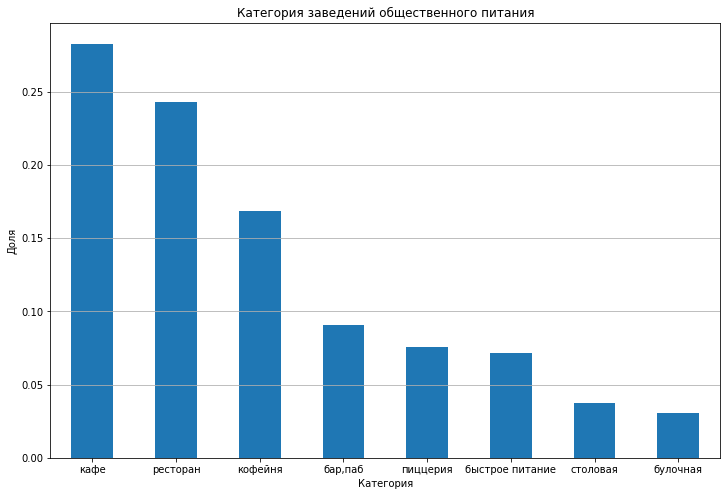

In [43]:
plt.figure(figsize=(12, 8))

df['category'].value_counts(normalize=True).plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Категория заведений общественного питания')

plt.xlabel('Категория')
plt.ylabel('Доля')
plt.grid(axis='y')
plt.show()

По результатам проверки категорий заведений общественного питания мы видим, что самые популярные заведения это кафе (2376) и рестораны (2042). Это указывает на высокий спрос на заведения со средним уровнем сервиса и разнообразным меню. Менее популярными категориями являются столовые (315) и булочные (256). 

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [44]:
display('Административные районы Москвы (абсолютные значения):')
df['district'].value_counts()

'Административные районы Москвы (абсолютные значения):'

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [45]:
display('Административные районы Москвы (в %):')
display(df['district'].value_counts(normalize=True) * 100)

'Административные районы Москвы (в %):'

Центральный административный округ         26.684123
Северный административный округ            10.687931
Южный административный округ               10.616520
Северо-Восточный административный округ    10.592716
Западный административный округ            10.116639
Восточный административный округ            9.497739
Юго-Восточный административный округ        8.497977
Юго-Западный административный округ         8.438467
Северо-Западный административный округ      4.867889
Name: district, dtype: float64

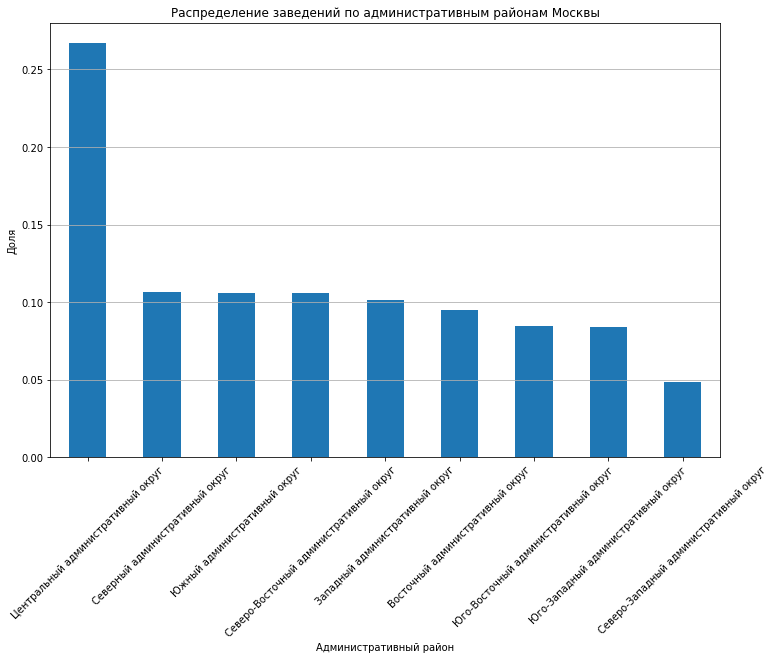

In [46]:
plt.figure(figsize=(12,8))

df['district'].value_counts(normalize=True).plot(
    kind='bar',
    rot=45,
    legend=False,
    title='Распределение заведений по административным районам Москвы')

plt.xlabel('Административный район')
plt.ylabel('Доля')
plt.grid(axis='y')
plt.show()

На основании полученных данных можно заметить, что большая часть заведений (2242) находятся в Центральном административном округе. Наименьшее число заведений (409) находится в Северо-Западном административном округе. Остальные округа имеют примерно одинаковую долю заведений (9-11%).

Определим распределение заведений каждой категории в Центральном административном округе Москвы.

In [47]:
cao_data = df[df['district'] == 'Центральный административный округ']

if cao_data.empty:
    print("В данных нет заведений из Центрального административного округа.")
else:
    print(f"В ЦАО найдено {len(cao_data)} заведений.")

    category_counts_cao = cao_data['category'].value_counts().sort_values(ascending=False)
    
    print("\nРаспределение категорий в ЦАО:")
    print(category_counts_cao)


В ЦАО найдено 2242 заведений.

Распределение категорий в ЦАО:
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64


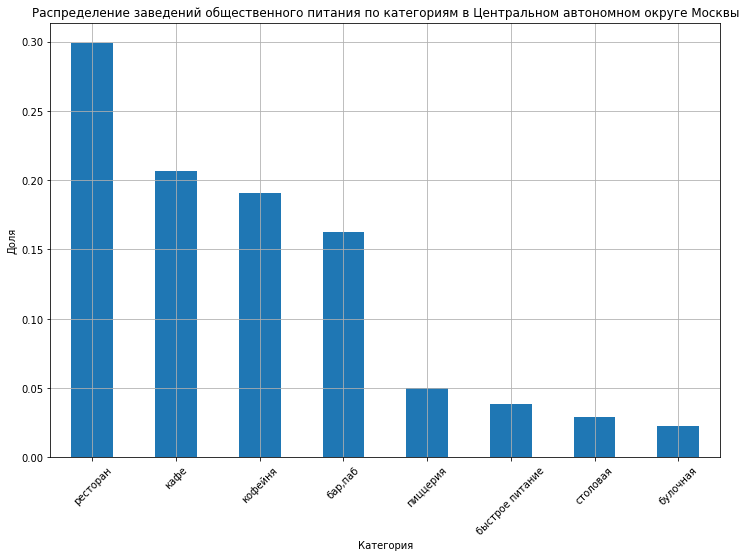

In [48]:
cao_data = df[df['district'] == 'Центральный административный округ']
category_cao = cao_data['category'].value_counts(normalize=True).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
category_cao.plot(
    kind='bar',
    rot=45,
    legend=False,
    title='Распределение заведений общественного питания по категориям в Центральном автономном округе Москвы'
)
plt.xlabel('Категория')
plt.ylabel('Доля')
plt.grid()
plt.show()

По результатам изучения распределения заведения в ЦАО мы видим, что больше всего в этом округе находится ресторанов (670). Можно предположить, что это связано, например, с большим туристическим потоком. Наимее популярными заведениями являются булочные (50), столовые (66), заведения быстрого питания (87) и пиццерии (113). Это в свою очередь может быть связано с тем, что в ЦАО меньше упор на стритфуд. Бары/пабы (364), кофейни (428) и кафе (464) находятся примерно на одинаковом уровне. 

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [49]:
total_counts = df['chain'].value_counts()
total_chain = total_counts.get(1, 0)
total_non_chain = total_counts.get(0, 0)

print(f"Сетевые заведения: {total_chain} ({total_chain / len(df):.1%})")
print(f"Несетевые заведения: {total_non_chain} ({total_non_chain / len(df):.1%})")

Сетевые заведения: 3203 (38.1%)
Несетевые заведения: 5199 (61.9%)


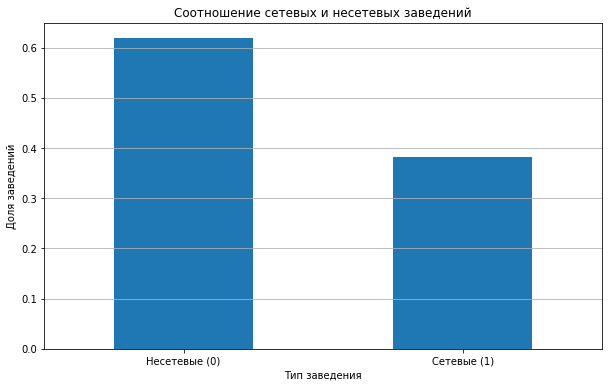

In [50]:
chain_dist = df['chain'].value_counts(normalize=True)
chain_dist.index = ['Несетевые (0)', 'Сетевые (1)']

plt.figure(figsize=(10, 6)) 
chain_dist.plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Соотношение сетевых и несетевых заведений'
)
plt.xlabel('Тип заведения')
plt.ylabel('Доля заведений')
plt.grid(axis='y')
plt.show()

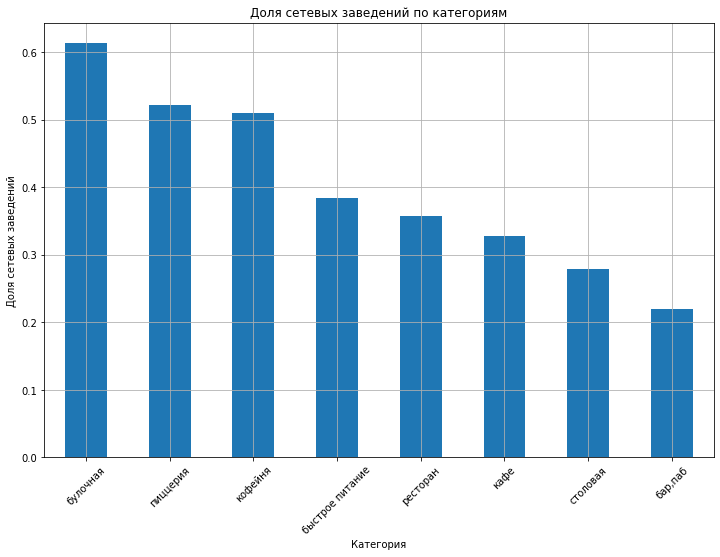

In [51]:
relation = (
    df
    .groupby('category')['chain']
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(12, 8))
relation.plot(
    kind='bar',
    rot=45,
    legend=False,
    title='Доля сетевых заведений по категориям'
)
plt.xlabel('Категория')
plt.ylabel('Доля сетевых заведений')
plt.grid()
plt.show()

По результатам можно сделать следующие выводы:
Всего сетевых заведений 3203 (38,1% от общего количества), тогда как несетевых заведений 5199 (61,9% от общего количества). Мы видим, что несетевых заведений гораздо больше.

Наибольшая доля сетевых заведений наблюдается в категории «булочная». Высокие доли также отмечены в категориях: «пиццерия» и «кофейня». Наименьшая доля сетевых заведений — в категории «бар/паб».

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [52]:
display(df['seats'].describe())

count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Среднее количество посадочных мест 108. При этом можно заметить, что 122,8 — большой разброс данных, что говорит о наличие значительных отклонений. 25% заведений имеют ≤ 40 мест, половина заведений имеет ≤ 75 мест.1 288 мест — экстремально большое заведение (выброс). 

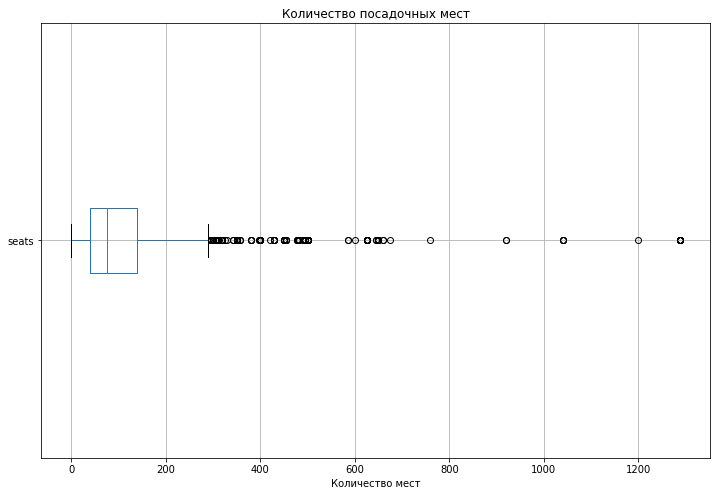

In [53]:
boxplot=df.boxplot(column='seats',
                  vert=False,
                  figsize=(12,8))

boxplot.set_title('Количество посадочных мест')
boxplot.set_xlabel('Количество мест')
plt.show()

"Ящик с усами" охватывает межквартильный размах (IQR) — от Q1 (40) до Q3 (140). 
Усы показывают диапазон «обычных» значений, за пределами которых начинаются выбросы.
Точки за усами отдельные точки справа — это аномально большие заведения (выбросы), Они сильно превышают Q3. Основная масса заведений сосредоточена в диапазоне 0–200 мест (видна плотность точек слева).
Заведения с количеством мест больше 140 лежат далеко за верхним усом ящика.
Возможные причины выбросов: ошибки ввода, сезонные заведения, наличие нескольких залов в заведении.

Дополнительно покажем распределение посадочных мест на гистограмме

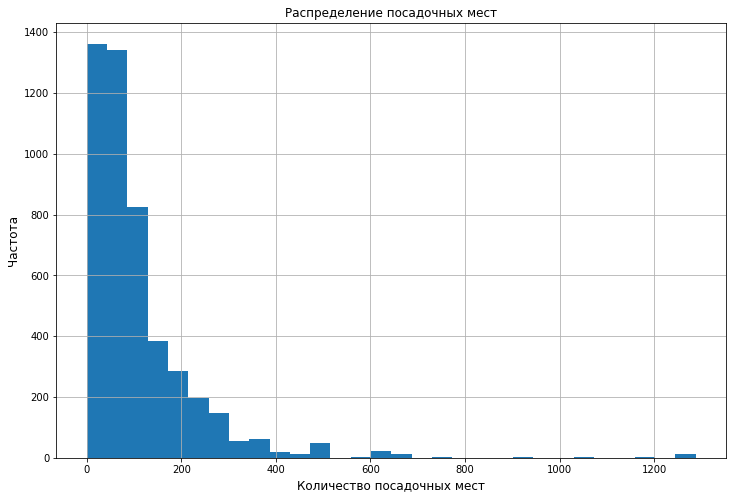

In [54]:
plt.figure(figsize=(12, 8))

df[df['seats'] != -1]['seats'].plot(
    kind='hist',
    bins=30,
    title='Распределение посадочных мест')

plt.xlabel('Количество посадочных мест', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid()
plt.show()

По полученной гистограмме мы видим, что пик распределения находится в диапазоне 0–100 посадочных мест: здесь наблюдается самая высокая частота (около 1400 заведений). Это говорит о том, что большинство заведений имеют небольшую вместимость.
Распределение имеет асимметричный (левосторонний) вид и также мы видим, что правый хвост (большие заведения) очень короткий и редкий.
И мы видим, что большинство заведений ориентированы на небольшую вместимость, а более крупные заведений практически отсутствуют.

In [55]:
typical_seats = df.groupby('category')['seats'].median()
display(typical_seats)

category
бар,паб            82.0
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: float32

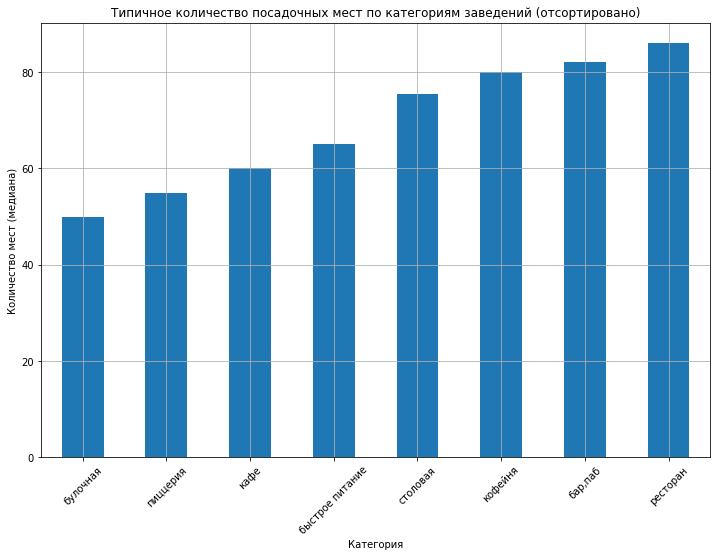

In [56]:
typical_seats = df.groupby('category')['seats'].median()

typical_seats_sorted = typical_seats.sort_values()

plt.figure(figsize=(12, 8))
typical_seats_sorted.plot(
    kind='bar',
    rot=45,
    legend=False,
    title='Типичное количество посадочных мест по категориям заведений (отсортировано)'
)
plt.xlabel('Категория')
plt.ylabel('Количество мест (медиана)')
plt.grid()
plt.show()

Наибольшее количество посадочных мест характерно для ресторанов. Второе по величине значение наблюдается у кофейни (80 мест) и бара/паба (82 места). Это говорит о том, что данные категории заведений также рассчитаны на достаточно большое количество посетителей. Наименьшая вместимость характерна булочной (50 мест) и пиццерии (55 мест) — форматы предполагает преимущественно "на вынос" или быстрое обслуживание. Разброс значений между категориями существенный (от 50 до 86 мест), что подчёркивает различия в концепции заведений.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [57]:
df.groupby('category')['rating'].describe().sort_values('count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
кафе,2376.0,4.124284,0.566001,1.0,4.0,4.2,4.4,5.0
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0


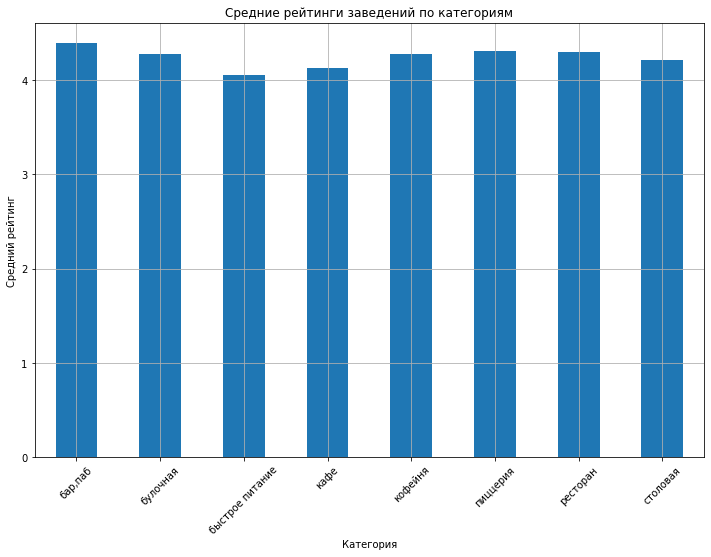

In [58]:
avg_ratings = df.groupby('category')['rating'].mean()
plt.figure(figsize=(12, 8))
avg_ratings.plot(
    kind='bar',
    rot=45,
    legend=False,
    title='Средние рейтинги заведений по категориям'
)
plt.xlabel('Категория')
plt.ylabel('Средний рейтинг')
plt.grid()
plt.show()

Средний рейтинг всех заведений составляет 4.2 (из 5), что можно считать достаточно высоким. Это говорит о том, что в целом заведения удовлетворяют ожидания посетителей.

На столбчатой диаграмме видно, что рейтинги по категориям распределены относительно равномерно.
Высокие рейтинги принадлежат кофейням, ресторанам, барам/пабам.
Средние рейтинги (около 4.2) принадлежат кафе, пиццериям, быстрому питание.
Чуть ниже среднего (около 4.1–4.2): булочные и столовые.
Рейтинги заведений по категориям демонстрируют умеренное различие, где максимальная разница между категориями визуально не превышает 0.2–0.3 балла.

Разрыв между рейтинга между баром, пабом (4.39) и быстрым питанием (4.05) составляет примерно 0.34 балла, что указывает на заметное отличие в восприятии клиентами. Возможно, в баре, пабе большее внимание уделяется качеству обслуживания, сервису, в связи с чем клиенты выбирают данный тип заведения нежели быстрое питание.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

interval columns not set, guessing: ['rating', 'chain', 'seats']


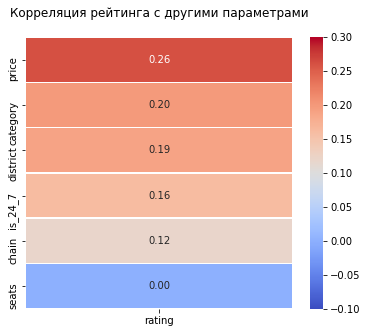

In [59]:
cols = ['category', 'district', 'rating', 'chain', 'seats', 'price', 'is_24_7']

df_for_corr = df[cols]

corr_matrix = phik_matrix(
    df=df_for_corr,
    drop_overflow=False
)

rating_corr = corr_matrix[['rating']].drop('rating', axis=0).sort_values(by='rating', ascending=False)

plt.figure(figsize=(6, 5))
sns.heatmap(rating_corr, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-0.1, 
            vmax=0.3,
            fmt=".2f", 
            linewidths=0.5)
plt.title('Корреляция рейтинга с другими параметрами', pad=20)
plt.show()

Самая высокая корреляция происходит со столбцом price (цена) - 0.26. Это говорит о том, что цена существенно влияет на рейтинг. Также достаточно высокая корреляция с категориями (0.20) и округом (0.19) - это значит, что категория заведения и её расположение также имеют весое значение для определения рейтинга.
Параметры количество мест и принадлежность к сети оказывают минимальное влияние на рейтинг.

In [60]:
avg_ratings = df.groupby('price')['rating'].mean()
display(avg_ratings)

price
высокие          4.436611
выше среднего    4.386348
низкие           4.173077
средние          4.297874
Name: rating, dtype: float32

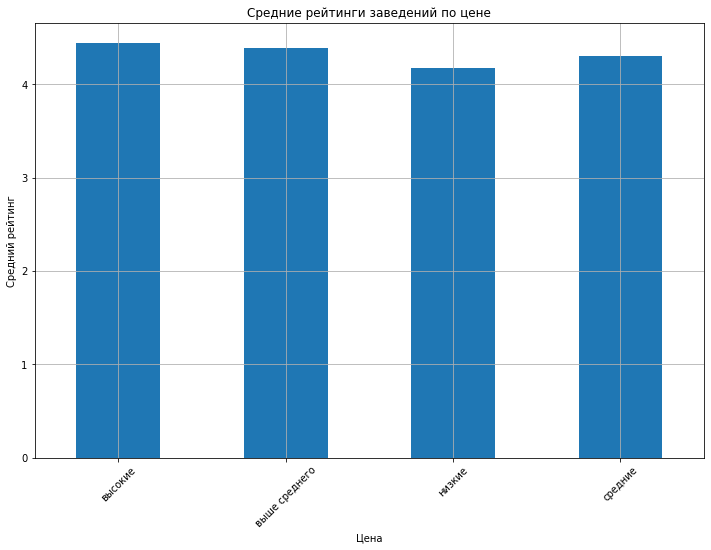

In [61]:
grouped = df.groupby('price')['rating'].mean()
grouped.plot(kind='bar',
               title=f'Средние рейтинги заведений по цене',
               legend=False,
               ylabel='Средний рейтинг',
               xlabel='Цена',
               rot=45,
               figsize=(12, 8))
plt.grid()
plt.show()

Общий уровень рейтинга заведений исхода из цены достаточно высокий. Все категории цен (высокие, выше среднего, низкие, средние) демонстрируют средние рейтинги около 4 баллов из 5, что говорит об общем уровне удовлетворённости клиентов в целом по выборке.
Разница в средних рейтингах между ценовыми сегментами практически минимальна — все столбцы примерно одной на одном уровне. Это может означать, что клиенты могут не соотносить цену и качество обслуживания, все заведения придерживаются одинаковых стандартов сервиса.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [62]:
chain_restaurants = df[df['chain'] == 1]
top_chain = chain_restaurants.groupby(['name', 'category']).agg(
    {'id': 'count', 'rating': 'mean'}
).sort_values(by='id', ascending=False).head(15)
top_chain = top_chain.reset_index()
display(top_chain)

,name,category,id,rating
0,шоколадница,кофейня,119,4.178151
1,домино'с пицца,пиццерия,76,4.169737
2,додо пицца,пиццерия,74,4.286487
3,one price coffee,кофейня,71,4.064789
4,яндекс лавка,ресторан,69,3.872464
5,cofix,кофейня,65,4.075385
6,prime,ресторан,49,4.114285
7,кофепорт,кофейня,42,4.147619
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
9,теремок,ресторан,36,4.105556


In [63]:
# Комментарий ревьюера 2
tmp = df.copy()          # создаем копию текущего датасета
name_tmp = 'му-му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


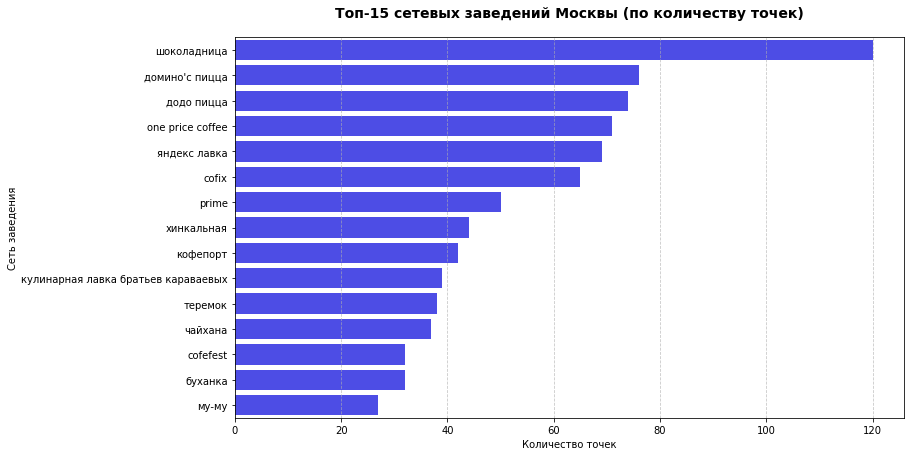

In [64]:
network_only = df[df['chain'] == 1]
top_15_networks = (
    network_only.groupby('name')
    .agg({
        'id': 'count',      
        'rating': 'mean'  
    })
    .rename(columns={'id': 'count_of_locations', 'rating': 'avg_rating'})
    .sort_values(by='count_of_locations', ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_15_networks,
    y='name',
    x='count_of_locations',
    color='blue',
    alpha=0.8
)

plt.title('Топ‑15 сетевых заведений Москвы (по количеству точек)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Количество точек')
plt.ylabel('Сеть заведения')


plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

На основе полученных данных мы видим, что наиболее популярным сетевым заведением в Москве является "Шоколадница", за ней идут "Домино'с Пицца", "Додо Пицца" и т.д.

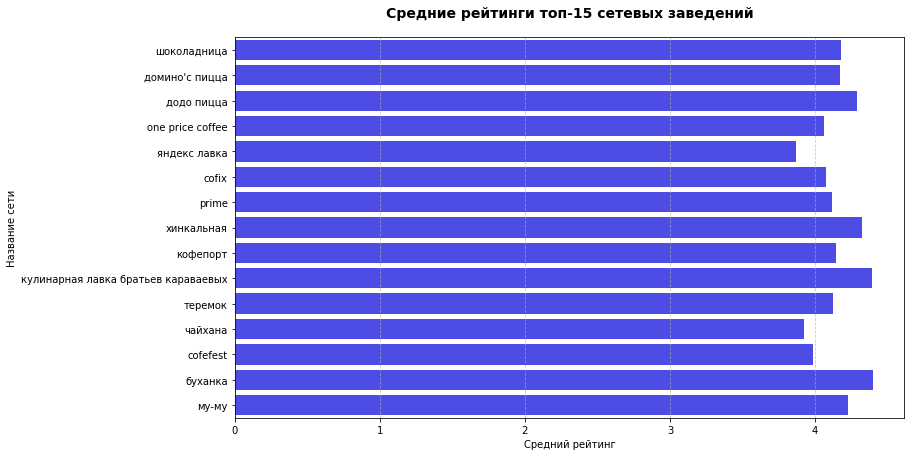

In [65]:
network_only = df[df['chain'] == 1]
top_15_networks = network_only.groupby('name').agg({
    'rating': 'mean',
    'id': 'count'
}).rename(columns={'id': 'count_of_locations'}).sort_values(
    by='count_of_locations', ascending=False
).head(15).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=top_15_networks, 
            y='name', 
            x='rating', 
            color='blue',
            alpha=0.8)

plt.title('Средние рейтинги топ-15 сетевых заведений', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

На основе представленных данных можно сделать вывод, что самыми популярными категориями заведений для топ-15 заведений Москвы являются - кофейни, пиццерии и рестораны. 
Также можно отметить, что в топе представлены различные виды заведений, включая, например, булочные. Это говорит о том, что формат быстрых перекусов также популярен.

На гистограмме мы видим, что пик заведений приходится на диапазон около 0–500 руб. по среднему чеку. Это говорит о том, что большинство заведений относится к бюджетному сегменту. После данного диапазона мы видим, что столбцы резко уменьшаются, т.е. основная масса заведений находится в низком ценовом сегменте, а премиальные заведения крайне редки.
Хвост распределения уходит вправо (к более высоким значениям чека), что также говорит о том, что премиального сегмента достаточно мало.
Можно сделать вывод, что большинство посетителей заведений предпочитают недорогие места (кофейни, кафе, пиццерии и т.д.)

In [69]:
district_stats = df.groupby('district')['middle_avg_bill'].agg([
    'mean', 'median'
]).round(2)

display(district_stats)

,mean,median
district,,
Восточный административный округ,820.630005,575.0
Западный административный округ,1053.229980,1000.0
Северный административный округ,927.960022,650.0
Северо-Восточный административный округ,716.609985,500.0
Северо-Западный административный округ,822.219971,700.0
Центральный административный округ,1191.060059,1000.0
Юго-Восточный административный округ,654.099976,450.0
Юго-Западный административный округ,792.559998,600.0
Южный административный округ,834.400024,500.0


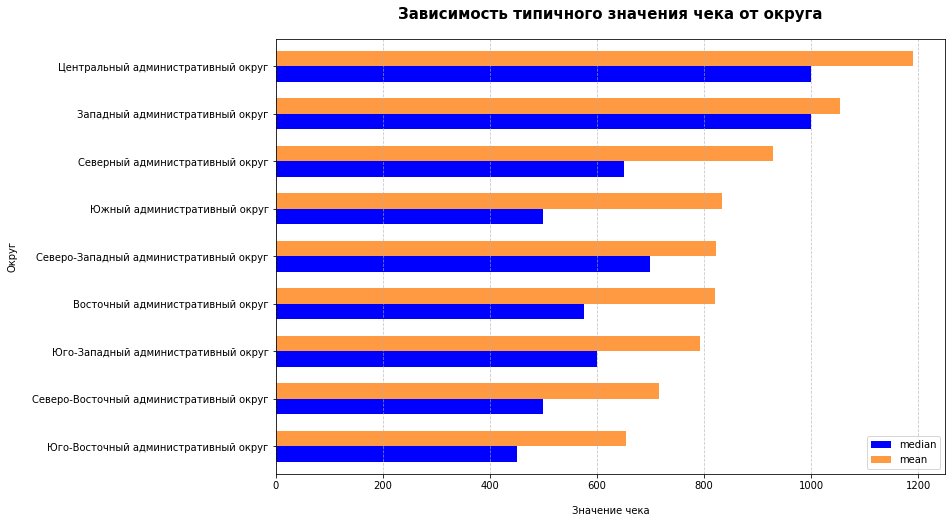

In [70]:
district_stats = df.groupby('district')['middle_avg_bill'].agg(['median','mean']).round(2)


district_stats_sorted = district_stats.sort_values('mean', ascending=True)

ax = district_stats_sorted.plot(
    kind='barh',
    color=['blue', '#ff9a42'], 
    width=0.65,
    figsize=(12, 8)
)

ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.set_title('Зависимость типичного значения чека от округа', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Значение чека', labelpad=15)
ax.set_ylabel('Округ', labelpad=15)
plt.show()

Исходя из полученных данных мы видим, что лидерами по среднему чеку (в руб.) являются Центральный административный округ (1221 руб.) и Западный административный округ (1104 руб.). Возможными причинами этого могут быть, высокая туристическая привлекательность, расположение бизнес-центров и т.д. 

Минимальный чек принадлежит Юго-Восточному административному округу (736 руб.) и Южному административну округу (845 руб.). Этот факт можно объяснить тем, что, возможно, данные районы являются более "спальными", меньше также ресторанов с высоким чеком, а также возможно, в этих округах выше доля населения с низкими доходами. Больше в таких округах, возможно, сконцентрированы заведения быстрого питания, столовые.
В Северном, Восточном, Юго-Западном и Северо-Восточном округах разница между средним и медианным чеком небольшая. Это может говорить о более равномерном распределении чеков.
На графике мы наглядно видим взаимосвязь между географическим расположением и платёжеспособностью потребителей, а также структуру спроса в разных округах Москвы.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

После проведения исследовательского анализа данных были получены следующие выводы:

1. Наиболее популярными категориями заведений общественного питания являются кафе (2376) и рестораны (2042). Менее популярными категориями являются столовые (315) и булочные (256).
2. Большая часть заведений (2242) находятся в Центральном административном округе. Наименьшее число заведений (409) находится в Северо-Западном административном округе. 
При этом в ЦАО в наиболее выигрышной позиции находятся рестораны (670 заведений).
3. Всего сетевых заведений 3203, а несетевых заведений 5199. При этом сетей булочных намного больше по соотношению к другим сетевым категориям заведений.
4. Больше всего посадочных мест у ресторанов (86), кофеен (80 мест) и баров/пабов (82 места). Наименьшее количество мест у булочных (50 мест) и пиццерий (55 мест) — форматы предполагает преимущественно «на вынос» или быстрое обслуживание.
5. Средний рейтинг всех заведений составляет 4.2 (из 5)
6. Топ-15 сетевых заведений Москвы включает в себя по большей части кафе и кофейни, а также пиццерии.
7. Лидирующим округом по среднему чеку является ЦАО (1221 руб.) и также видна непосредственная взаимосвязь между территориальной удаленностью от центра (снижение среднего чека).

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

**Общий обзор проделанной работы**

В ходе проведения исследовательского анализа рынка общественного питания Москвы было проанализировано более 8 тысяч данных. Полученные данные раскрывали информацию о наименовании заведения, его категории, рейтингу, территориальной принадлежности, средней цене и т.д.
После загрузки и предобработки данных проведён анализ:

* распределение заведений по категориям и округам;

* соотношение сетевых и несетевых форматов;

* вместимость заведений и выбросы;

* рейтинги и их корреляции;

* топовые сети;

* вариация среднего чека по округам.

**Ответы на исследовательские вопросы / главные выводы**
1. Лидеры по количеству заведений в Москве: кафе (2 376) и рестораны (2 042). А менее представлены: столовые (315) и булочные (256).
2. В географическом отношении лидером является Центральный административный округ (2242 заведения), в 5,5 раз больше, чем в Северо‑Западном административном округе (409). При этом в В ЦАО доминирующую позицию занимают рестораны (670), кафе (464) и кофейни (428).
3. Всего было получено данных о 3203 сетевых заведений (при этом несетевых 5199). К самым «сетевым» категориям относятся: булочные, кофейни, пиццерии, рестораны.
4. Исходя из топ-15 заведений можно сделать вывод, что кофейни и пиццерии — самые масштабируемые форматы.
5. Информация о среднем чеке по округам также дает сделать вывод, что географическое расположение сильно влияет на популярность заведения (ЦАО: 1 221 руб. чек; ЮВАО: 736 руб.чек).

**Рекомендации на основе анализа данных**
1. В качестве приоритетной локации лучше выбрать Западный и Северный административные округа: баланс между плотностью заведений и стоимостью входа. В ЦАО наблюдается достаточно высокая плотность заведений и большая концуренция.
2. В качестве форматов заведения можно выбрать кофейни и пиццерии, ввиду высокого потенциала в качестве сетевых проектов. Булочные и столовые требуют нестандартного подхода и уникального позиционирования.
Можно также попробовать внедрить гибридные модели: кафе с зоной самовывоза, рестораны с возможностью доставки, кофейни с мини‑пекарнями.